Variational Autoencoder (VAE)

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [57]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [58]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, 2)     # latent dim = 2
        self.fc_logvar = nn.Linear(400, 2)
        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [59]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [60]:
def loss_fn(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [61]:
for epoch in range(3):
    for x, _ in loader:
        x = x.view(-1, 28*28)
        
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 16251.2783203125
Epoch 2, Loss: 14961.0830078125
Epoch 3, Loss: 15739.099609375


In [62]:
with torch.no_grad():
    z_list = []
    labels = []

    for x, y in loader:
        x = x.view(-1, 28*28)
        mu, _ = model.encode(x)
        z_list.append(mu)
        labels.append(y)
        break

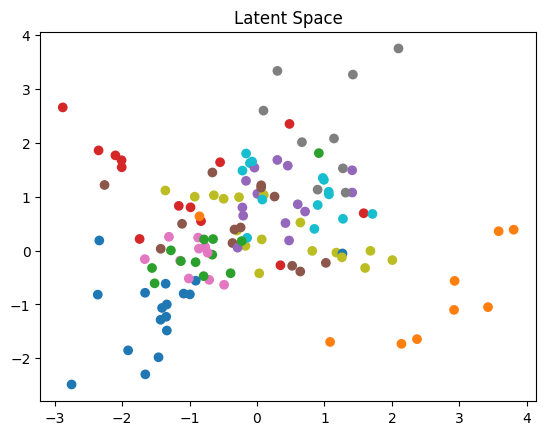

In [63]:
z = torch.cat(z_list).numpy()
labels = torch.cat(labels).numpy()

plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10')
plt.title("Latent Space")
plt.show()

GAN for Image Generation

In [64]:
import torch.nn as nn

latent_dim = 100

In [65]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [66]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [67]:
G = Generator()
D = Discriminator()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

loss_fn = nn.BCELoss()

In [68]:
for epoch in range(3):
    for i, (real, _) in enumerate(loader):

        if i == 50:
            break

        real = real.view(-1, 784)

        real_labels = torch.ones(real.size(0), 1)
        fake_labels = torch.zeros(real.size(0), 1)

        z = torch.randn(real.size(0), latent_dim)
        fake = G(z)

      
        loss_real = loss_fn(D(real), real_labels)
        loss_fake = loss_fn(D(fake.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

     
        loss_G = loss_fn(D(fake), real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Step {i}, D Loss: {loss_D.item()}, G Loss: {loss_G.item()}")

Epoch 1, Step 0, D Loss: 1.4013597965240479, G Loss: 0.6966204643249512
Epoch 1, Step 10, D Loss: 1.1491352319717407, G Loss: 0.6797182559967041
Epoch 1, Step 20, D Loss: 1.091395616531372, G Loss: 0.6039073467254639
Epoch 1, Step 30, D Loss: 1.1938717365264893, G Loss: 0.5144294500350952
Epoch 1, Step 40, D Loss: 1.2400109767913818, G Loss: 0.5659422874450684
Epoch 2, Step 0, D Loss: 1.3741915225982666, G Loss: 0.6811259984970093
Epoch 2, Step 10, D Loss: 1.7066305875778198, G Loss: 0.6308706998825073
Epoch 2, Step 20, D Loss: 1.8753535747528076, G Loss: 0.6085917949676514
Epoch 2, Step 30, D Loss: 1.536268949508667, G Loss: 0.7950998544692993
Epoch 2, Step 40, D Loss: 1.1686716079711914, G Loss: 1.029207468032837
Epoch 3, Step 0, D Loss: 0.8996533155441284, G Loss: 1.2269983291625977
Epoch 3, Step 10, D Loss: 0.6946821212768555, G Loss: 1.4711735248565674
Epoch 3, Step 20, D Loss: 0.5552369356155396, G Loss: 1.6621620655059814
Epoch 3, Step 30, D Loss: 0.4837861657142639, G Loss: 1.7

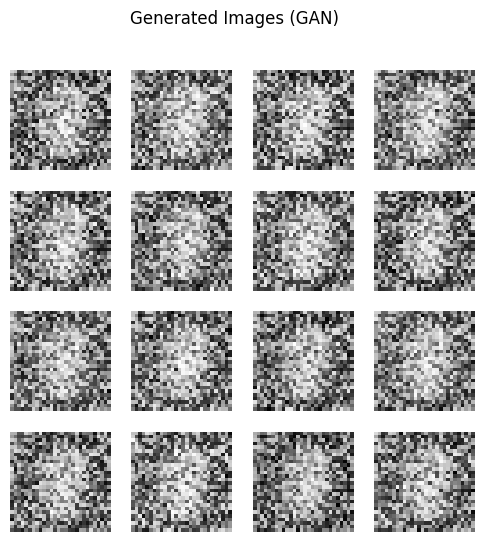

In [69]:
import matplotlib.pyplot as plt


z = torch.randn(16, latent_dim)
fake_images = G(z).detach().view(-1, 28, 28)


plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(fake_images[i], cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Images (GAN)")
plt.show()

Graph Convolutional Network (GCN)

In [70]:
!pip install torch-geometric

In [71]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

dataset = Planetoid(root='data', name='Cora')
data = dataset[0]

In [72]:

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


In [73]:
model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [74]:
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()

print("Training complete")

Training complete


In [75]:
model.eval()
pred = model(data.x, data.edge_index).argmax(dim=1)
acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

print("Test Accuracy:", acc)

Test Accuracy: 0.78


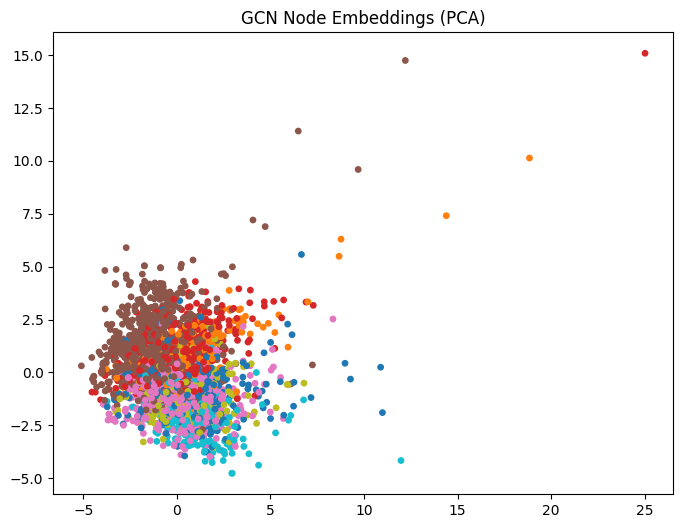

In [76]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()

with torch.no_grad():
    x = model.conv1(data.x, data.edge_index)
    x = x.cpu().numpy()


pca = PCA(n_components=2)
x_2d = pca.fit_transform(x)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x_2d[:,0], x_2d[:,1], c=data.y.cpu(), cmap='tab10', s=15)
plt.title("GCN Node Embeddings (PCA)")
plt.show()

In [77]:
pred = model(data.x, data.edge_index).argmax(dim=1)

print("Sample Predictions vs Actual:")
for i in range(10):
    print(f"Pred: {pred[i].item()} | Actual: {data.y[i].item()}")

Sample Predictions vs Actual:
Pred: 3 | Actual: 3
Pred: 4 | Actual: 4
Pred: 4 | Actual: 4
Pred: 0 | Actual: 0
Pred: 3 | Actual: 3
Pred: 2 | Actual: 2
Pred: 0 | Actual: 0
Pred: 3 | Actual: 3
Pred: 3 | Actual: 3
Pred: 2 | Actual: 2
